# Módulo 7 - Persona 4
## Evaluación y optimización del modelo

Esta sección desarrolla:
- Validación cruzada estratificada
- Ajuste de hiperparámetros
- Comparación entre modelos
- Evaluación con Accuracy, Precision, Recall, F1 Score y Matriz de Confusión

Modelos evaluados:
1. Regresión Logística multinomial
2. Random Forest
3. Gradient Boosting

Hipótesis relacionada:
- H4. Se espera que los modelos ensemble (Random Forest y Gradient Boosting) presenten un desempeño predictivo superior al de la Regresión Logística como modelo base.

In [1]:
#Librerías

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [15]:
# Configuración General

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_SPLITS = 3
SCORING_REFIT = "f1_weighted"

DATA_PATH = Path("processed_matches.csv")
OUTPUT_DIR = Path("outputs_persona4")
OUTPUT_DIR.mkdir(exist_ok=True)

TARGET_LABELS = {
    0: "Lose",
    1: "Draw",
    2: "Win"
}

RUN_FEATURE_ABLATION = True

In [16]:
# Funciones Auxiliares

def print_section(title: str):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

def ks_statistic(y_true_binary, y_prob):
    fpr, tpr, _ = roc_curve(y_true_binary, y_prob)
    return np.max(tpr - fpr)

def get_class_names(classes_array):
    return [TARGET_LABELS.get(int(c), str(c)) for c in classes_array]

In [17]:
# Carga de datos

print_section("CARGA DE DATOS")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo {DATA_PATH}. "
        "Asegúrate de que processed_matches.csv esté en la misma carpeta del notebook."
    )

df = pd.read_csv(DATA_PATH)
print(f"Shape inicial: {df.shape}")
display(df.head())


CARGA DE DATOS
Shape inicial: (49971, 209)


,home_rank_position,home_rank_points,away_rank_position,away_rank_points,rank_points_diff,year,neutral,has_shootout,tourn_AFC Asian Cup,tourn_AFC Asian Cup qualification,...,tourn_World Unity Cup,tourn_Zambian Independence Tournament,tourn_Évence Coppée Trophy,home_score,away_score,ranking_diff,goal_diff,result,is_home,ranking_scaled
0,38.0,1506.77,4.0,1834.12,-327.35,1872,0,0,False,False,...,False,False,False,0.0,0.0,-327.35,0.0,draw,1,0.512611
1,4.0,1834.12,38.0,1506.77,327.35,1873,0,0,False,False,...,False,False,False,4.0,2.0,327.35,2.0,win,1,1.798387
2,38.0,1506.77,4.0,1834.12,-327.35,1874,0,0,False,False,...,False,False,False,2.0,1.0,-327.35,1.0,win,1,0.512611
3,4.0,1834.12,38.0,1506.77,327.35,1875,0,0,False,False,...,False,False,False,2.0,2.0,327.35,0.0,draw,1,1.798387
4,38.0,1506.77,4.0,1834.12,-327.35,1876,0,0,False,False,...,False,False,False,3.0,0.0,-327.35,3.0,win,1,0.512611


In [18]:
# Validación de Columnas mínimas

required_columns = [
    "home_rank_position",
    "home_rank_points",
    "away_rank_position",
    "away_rank_points",
    "home_score",
    "away_score",
    "has_shootout",
    "neutral"
]

missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"Faltan columnas requeridas en el dataset: {missing}")

print("Columnas mínimas validadas correctamente.")

Columnas mínimas validadas correctamente.


In [19]:
# Feature Engineering

print_section("FEATURE ENGINEERING")

df["rank_position_diff"] = df["away_rank_position"] - df["home_rank_position"]
df["rank_points_diff"] = df["home_rank_points"] - df["away_rank_points"]
df["rank_points_sum"] = df["home_rank_points"] + df["away_rank_points"]
df["rank_points_ratio"] = df["home_rank_points"] / (df["away_rank_points"] + 1)
df["abs_rank_points_diff"] = df["rank_points_diff"].abs()

df["log_home_rank_points"] = np.log1p(df["home_rank_points"])
df["log_away_rank_points"] = np.log1p(df["away_rank_points"])
df["inv_home_rank_position"] = 1 / (df["home_rank_position"] + 1)
df["inv_away_rank_position"] = 1 / (df["away_rank_position"] + 1)

df["is_close_match"] = (df["abs_rank_points_diff"] < 50).astype(int)

df["has_shootout"] = df["has_shootout"].fillna(0).astype(int)
df["neutral"] = df["neutral"].fillna(0).astype(int)

# Target multiclase:
# 0 = derrota local, 1 = empate, 2 = victoria local
df["target"] = np.select(
    [
        df["home_score"] < df["away_score"],
        df["home_score"] == df["away_score"],
        df["home_score"] > df["away_score"]
    ],
    [0, 1, 2]
).astype(int)

print("Distribución del target:")
display(
    df["target"]
    .value_counts()
    .sort_index()
    .rename(index=TARGET_LABELS)
    .to_frame("count")
)


FEATURE ENGINEERING
Distribución del target:


,count
target,
Lose,14123
Draw,11349
Win,24499


In [20]:
#Definición de Features

tournament_features = [col for col in df.columns if col.startswith("tourn_")]

for col in tournament_features:
    df[col] = df[col].fillna(0).apply(lambda x: 1 if x > 0 else 0)

rank_features = [
    "home_rank_position",
    "home_rank_points",
    "away_rank_position",
    "away_rank_points",
    "rank_points_diff"
]

engineered_features = [
    "rank_position_diff",
    "rank_points_sum",
    "rank_points_ratio",
    "abs_rank_points_diff",
    "log_home_rank_points",
    "log_away_rank_points",
    "inv_home_rank_position",
    "inv_away_rank_position",
    "is_close_match"
]

other_features = [
    "year",
    "neutral",
    "has_shootout"
]

candidate_features = rank_features + engineered_features + other_features + tournament_features
features = [f for f in candidate_features if f in df.columns]

if len(features) == 0:
    raise ValueError("No se encontraron features válidas en el dataset.")

print_section("FEATURES FINALES")
print(f"Número de features: {len(features)}")
print(features)

X = df[features].copy()
y = df["target"].copy()


FEATURES FINALES
Número de features: 211
['home_rank_position', 'home_rank_points', 'away_rank_position', 'away_rank_points', 'rank_points_diff', 'rank_position_diff', 'rank_points_sum', 'rank_points_ratio', 'abs_rank_points_diff', 'log_home_rank_points', 'log_away_rank_points', 'inv_home_rank_position', 'inv_away_rank_position', 'is_close_match', 'year', 'neutral', 'has_shootout', 'tourn_AFC Asian Cup', 'tourn_AFC Asian Cup qualification', 'tourn_AFC Challenge Cup', 'tourn_AFC Challenge Cup qualification', 'tourn_AFF Championship', 'tourn_AFF Championship qualification', 'tourn_ASEAN Championship', 'tourn_ASEAN Championship qualification', 'tourn_African Cup of Nations', 'tourn_African Cup of Nations qualification', 'tourn_African Friendship Games', 'tourn_Afro-Asian Games', 'tourn_Al Ain International Cup', 'tourn_All-African Games', 'tourn_Amílcar Cabral Cup', 'tourn_Arab Cup', 'tourn_Arab Cup qualification', 'tourn_Asian Games', 'tourn_Atlantic Cup', 'tourn_Atlantic Heritage Cup',

In [21]:
# Split train/test

print_section("TRAIN / TEST SPLIT")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

print("\nDistribución y_train:")
display(
    y_train.value_counts(normalize=True)
    .sort_index()
    .rename(index=TARGET_LABELS)
    .round(4)
    .to_frame("proportion")
)

print("\nDistribución y_test:")
display(
    y_test.value_counts(normalize=True)
    .sort_index()
    .rename(index=TARGET_LABELS)
    .round(4)
    .to_frame("proportion")
)


TRAIN / TEST SPLIT
X_train: (39976, 211) | X_test: (9995, 211)

Distribución y_train:


,proportion
target,
Lose,0.2826
Draw,0.2271
Win,0.4903



Distribución y_test:


,proportion
target,
Lose,0.2826
Draw,0.2271
Win,0.4902


In [22]:
# Función para GridSearch + Validación Cruzada

def run_grid_search(
    model_name,
    estimator,
    param_grid,
    X_train,
    y_train,
    use_scaling=False
):
    print_section(f"GRID SEARCH + VALIDACIÓN CRUZADA - {model_name}")

    numeric_features = X_train.columns.tolist()

    if use_scaling:
        preprocessor = ColumnTransformer(
            transformers=[
                ("num", Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]), numeric_features)
            ],
            remainder="drop"
        )

        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", estimator)
        ])
    else:
        pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", estimator)
        ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=SCORING_REFIT,
        cv=StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=-1,
        refit=True,
        verbose=1
    )

    grid.fit(X_train, y_train)

    print("Mejores parámetros:")
    print(grid.best_params_)
    print(f"Mejor F1-weighted CV: {grid.best_score_:.4f}")

    scoring = {
        "accuracy": "accuracy",
        "precision_weighted": "precision_weighted",
        "recall_weighted": "recall_weighted",
        "f1_weighted": "f1_weighted"
    }

    cv_results = cross_validate(
        grid.best_estimator_,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_summary = {
        "model": model_name,
        "cv_accuracy_mean": round(float(np.mean(cv_results["test_accuracy"])), 4),
        "cv_accuracy_std": round(float(np.std(cv_results["test_accuracy"])), 4),
        "cv_precision_weighted_mean": round(float(np.mean(cv_results["test_precision_weighted"])), 4),
        "cv_recall_weighted_mean": round(float(np.mean(cv_results["test_recall_weighted"])), 4),
        "cv_f1_weighted_mean": round(float(np.mean(cv_results["test_f1_weighted"])), 4),
        "best_params": grid.best_params_
    }

    return grid.best_estimator_, cv_summary, grid

In [23]:
# Función de Evaluación Final

def evaluate_model(model_name, fitted_model, X_test, y_test, classes_reference=(0, 1, 2)):
    print_section(f"EVALUACIÓN FINAL - {model_name}")

    y_pred = fitted_model.predict(X_test)

    if hasattr(fitted_model, "predict_proba"):
        y_proba = fitted_model.predict_proba(X_test)
    else:
        y_proba = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    labels_sorted = list(classes_reference)
    cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
    cm_df = pd.DataFrame(
        cm,
        index=[f"Real_{TARGET_LABELS.get(c, c)}" for c in labels_sorted],
        columns=[f"Pred_{TARGET_LABELS.get(c, c)}" for c in labels_sorted]
    )

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusión - {model_name}")
    plt.tight_layout()
    plt.show()

    report = classification_report(
        y_test,
        y_pred,
        labels=labels_sorted,
        target_names=[TARGET_LABELS.get(c, str(c)) for c in labels_sorted],
        zero_division=0
    )
    print("\nReporte de clasificación:")
    print(report)

    auc_macro = np.nan
    auc_weighted = np.nan
    gini_macro = np.nan
    ks_per_class = {}

    if y_proba is not None:
        y_test_bin = label_binarize(y_test, classes=labels_sorted)

        try:
            auc_macro = roc_auc_score(
                y_test_bin,
                y_proba,
                average="macro",
                multi_class="ovr"
            )
            auc_weighted = roc_auc_score(
                y_test_bin,
                y_proba,
                average="weighted",
                multi_class="ovr"
            )
            gini_macro = 2 * auc_macro - 1

            print(f"\nAUC Macro   : {auc_macro:.4f}")
            print(f"AUC Weighted: {auc_weighted:.4f}")
            print(f"Gini Macro  : {gini_macro:.4f}")

            plt.figure(figsize=(8, 6))
            for i, class_label in enumerate(labels_sorted):
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
                plt.plot(fpr, tpr, label=f"{TARGET_LABELS.get(class_label, class_label)}")
                ks_value = ks_statistic(y_test_bin[:, i], y_proba[:, i])
                ks_per_class[TARGET_LABELS.get(class_label, str(class_label))] = round(float(ks_value), 4)

            plt.plot([0, 1], [0, 1], "k--")
            plt.title(f"Curvas ROC Multiclase - {model_name}")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.legend()
            plt.tight_layout()
            plt.show()

            print("\nKS por clase:")
            print(ks_per_class)

        except Exception as e:
            print(f"No se pudo calcular AUC/ROC: {e}")

    return {
        "model": model_name,
        "test_accuracy": round(float(acc), 4),
        "test_precision_weighted": round(float(prec), 4),
        "test_recall_weighted": round(float(rec), 4),
        "test_f1_weighted": round(float(f1), 4),
        "test_auc_macro_ovr": round(float(auc_macro), 4) if not pd.isna(auc_macro) else np.nan,
        "test_auc_weighted_ovr": round(float(auc_weighted), 4) if not pd.isna(auc_weighted) else np.nan,
        "test_gini_macro": round(float(gini_macro), 4) if not pd.isna(gini_macro) else np.nan,
        "ks_per_class": ks_per_class
    }

In [24]:
# Función para "Importancia de Variables"

def plot_feature_importance(model_name, best_estimator, feature_names):
    importances_df = None

    if hasattr(best_estimator, "feature_importances_"):
        importances = best_estimator.feature_importances_
        importances_df = pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        }).sort_values("importance", ascending=False)

    elif hasattr(best_estimator, "coef_"):
        coefs = np.abs(best_estimator.coef_)
        if coefs.ndim == 2:
            importances = coefs.mean(axis=0)
        else:
            importances = coefs

        importances_df = pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        }).sort_values("importance", ascending=False)

    if importances_df is not None:
        display(importances_df.head(15))

        plt.figure(figsize=(10, 6))
        sns.barplot(data=importances_df.head(15), x="importance", y="feature")
        plt.title(f"Top 15 variables importantes - {model_name}")
        plt.tight_layout()
        plt.show()

    return importances_df

In [25]:
# Configuración de Modelos y Grids

models_config = {
    "logistic_regression": {
        "estimator": LogisticRegression(
            solver="lbfgs",
            max_iter=3000,
            class_weight="balanced"
        ),
        "use_scaling": True,
        "param_grid": {
            "model__C": [0.01, 0.1, 1, 5, 10]
        }
    },
    "random_forest": {
        "estimator": RandomForestClassifier(
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ),
        "use_scaling": False,
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2],
            "model__max_features": ["sqrt", None]
        }
    },
    "gradient_boosting": {
        "estimator": GradientBoostingClassifier(
            random_state=RANDOM_STATE
        ),
        "use_scaling": False,
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3],
            "model__subsample": [0.8, 1.0]
        }
    }
}

In [26]:
# Entrenamiento, tunning y CV

best_models = {}
cv_rows = []
grid_objects = {}

for model_name, cfg in models_config.items():
    best_estimator, cv_summary, grid_obj = run_grid_search(
        model_name=model_name,
        estimator=cfg["estimator"],
        param_grid=cfg["param_grid"],
        X_train=X_train,
        y_train=y_train,
        use_scaling=cfg["use_scaling"]
    )

    best_models[model_name] = best_estimator
    cv_rows.append(cv_summary)
    grid_objects[model_name] = grid_obj


GRID SEARCH + VALIDACIÓN CRUZADA - logistic_regression
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Mejores parámetros:
{'model__C': 1}
Mejor F1-weighted CV: 0.5120

GRID SEARCH + VALIDACIÓN CRUZADA - random_forest
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Mejores parámetros:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Mejor F1-weighted CV: 0.5371

GRID SEARCH + VALIDACIÓN CRUZADA - gradient_boosting
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Mejores parámetros:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Mejor F1-weighted CV: 0.5115


In [27]:
# Resumen de Validación Cruzada

cv_df = pd.DataFrame(cv_rows)
cv_df

,model,cv_accuracy_mean,cv_accuracy_std,cv_precision_weighted_mean,cv_recall_weighted_mean,cv_f1_weighted_mean,best_params
0,logistic_regression,0.5061,0.0035,0.5256,0.5061,0.5120,{'model__C': 1}
1,random_forest,0.5391,0.0035,0.5370,0.5391,0.5371,"{'model__max_depth': None, 'model__max_feature..."
2,gradient_boosting,0.5739,0.0016,0.5885,0.5739,0.5115,"{'model__learning_rate': 0.1, 'model__max_dept..."



EVALUACIÓN FINAL - logistic_regression
Accuracy : 0.5083
Precision: 0.5277
Recall   : 0.5083
F1 Score : 0.5137


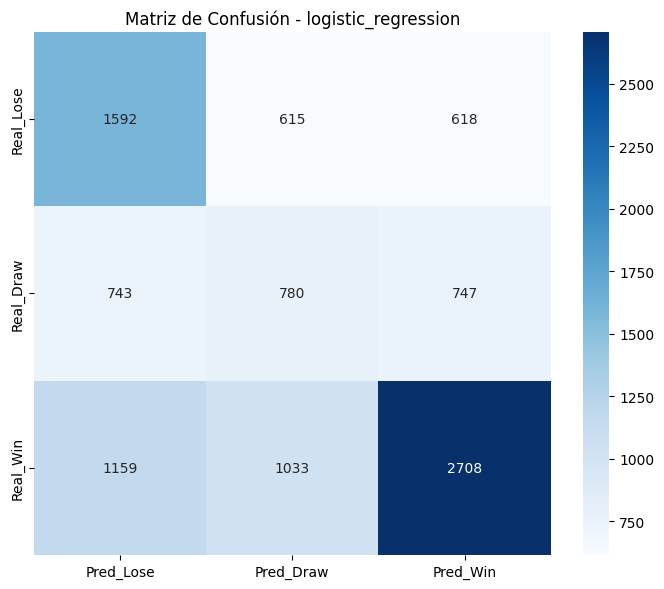


Reporte de clasificación:
              precision    recall  f1-score   support

        Lose       0.46      0.56      0.50      2825
        Draw       0.32      0.34      0.33      2270
         Win       0.66      0.55      0.60      4900

    accuracy                           0.51      9995
   macro avg       0.48      0.49      0.48      9995
weighted avg       0.53      0.51      0.51      9995


AUC Macro   : 0.6776
AUC Weighted: 0.6867
Gini Macro  : 0.3551


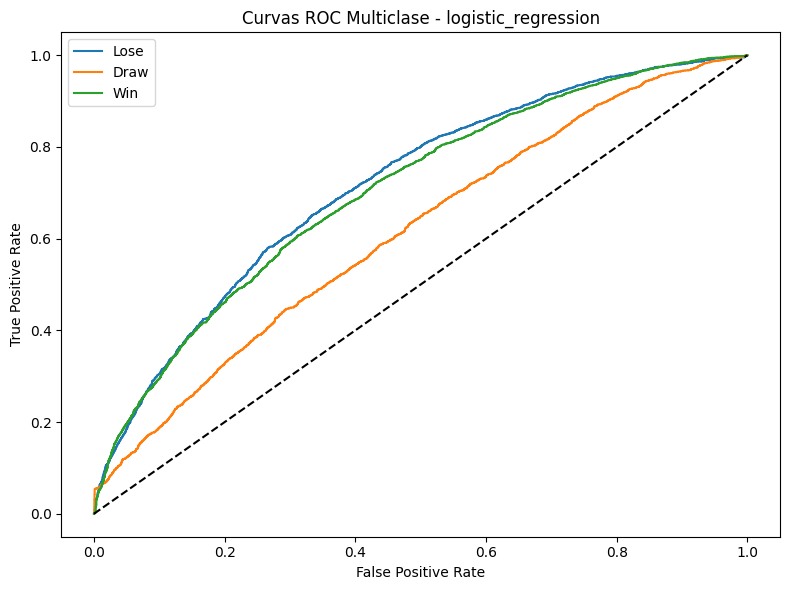


KS por clase:
{'Lose': 0.3175, 'Draw': 0.1526, 'Win': 0.295}

EVALUACIÓN FINAL - random_forest
Accuracy : 0.5389
Precision: 0.5383
Recall   : 0.5389
F1 Score : 0.5377


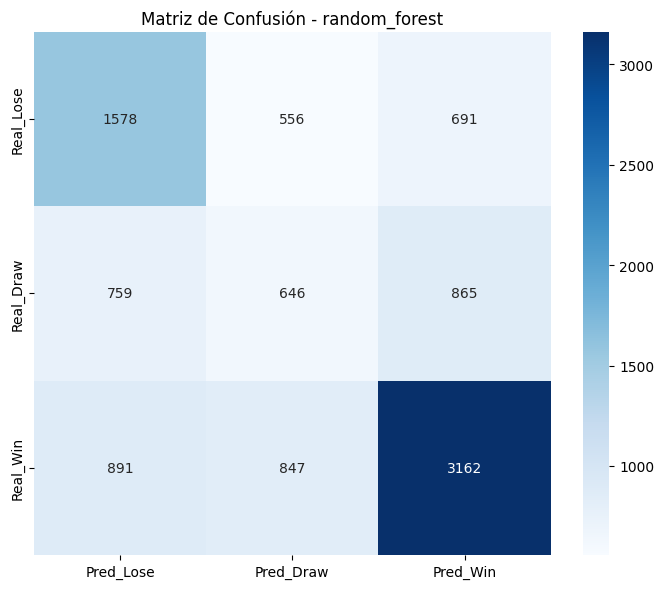


Reporte de clasificación:
              precision    recall  f1-score   support

        Lose       0.49      0.56      0.52      2825
        Draw       0.32      0.28      0.30      2270
         Win       0.67      0.65      0.66      4900

    accuracy                           0.54      9995
   macro avg       0.49      0.50      0.49      9995
weighted avg       0.54      0.54      0.54      9995


AUC Macro   : 0.6957
AUC Weighted: 0.7102
Gini Macro  : 0.3913


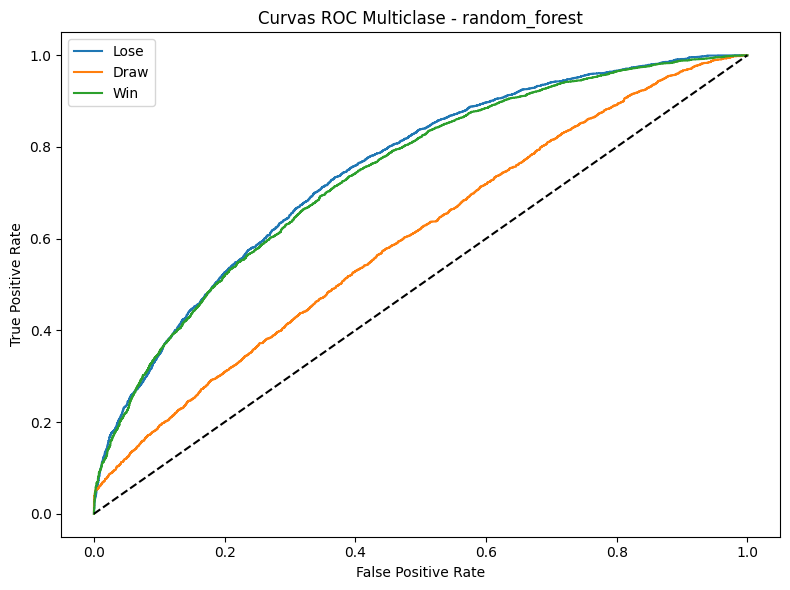


KS por clase:
{'Lose': 0.3654, 'Draw': 0.1317, 'Win': 0.3461}

EVALUACIÓN FINAL - gradient_boosting
Accuracy : 0.5771
Precision: 0.5990
Recall   : 0.5771
F1 Score : 0.5146


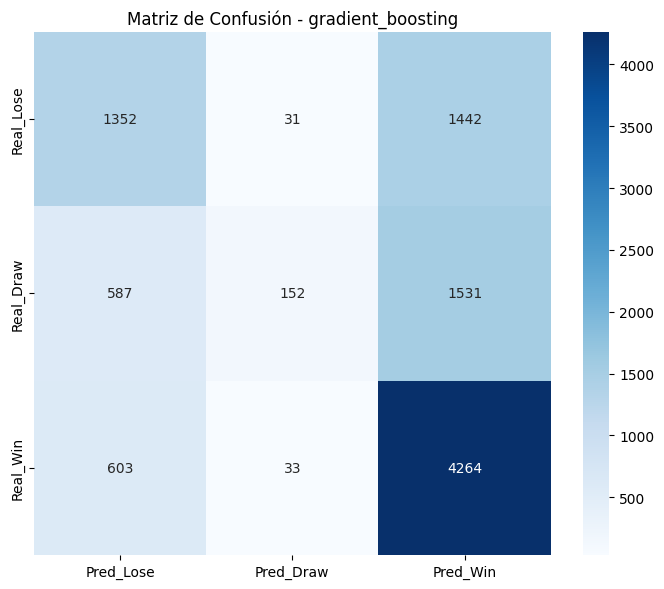


Reporte de clasificación:
              precision    recall  f1-score   support

        Lose       0.53      0.48      0.50      2825
        Draw       0.70      0.07      0.12      2270
         Win       0.59      0.87      0.70      4900

    accuracy                           0.58      9995
   macro avg       0.61      0.47      0.44      9995
weighted avg       0.60      0.58      0.51      9995


AUC Macro   : 0.7058
AUC Weighted: 0.7159
Gini Macro  : 0.4115


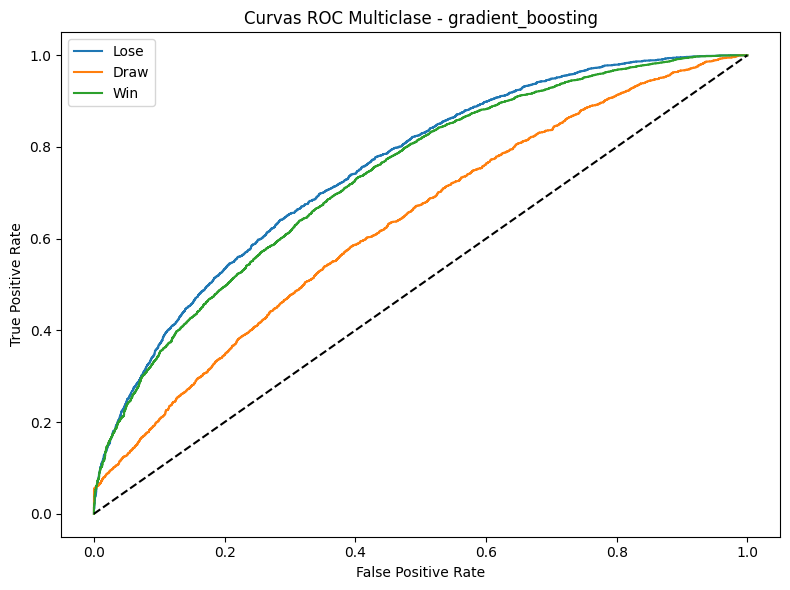


KS por clase:
{'Lose': 0.3558, 'Draw': 0.1893, 'Win': 0.33}


In [28]:
# Evaluación Final en Test

test_rows = []

for model_name, best_estimator in best_models.items():
    test_summary = evaluate_model(
        model_name=model_name,
        fitted_model=best_estimator,
        X_test=X_test,
        y_test=y_test,
        classes_reference=(0, 1, 2)
    )
    test_rows.append(test_summary)

In [29]:
# Tabla Comparativa Final

test_df = pd.DataFrame(test_rows)
comparison_df = cv_df.merge(test_df, on="model", how="left")
comparison_df = comparison_df.sort_values("test_f1_weighted", ascending=False)
comparison_df

,model,cv_accuracy_mean,cv_accuracy_std,cv_precision_weighted_mean,cv_recall_weighted_mean,cv_f1_weighted_mean,best_params,test_accuracy,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_auc_macro_ovr,test_auc_weighted_ovr,test_gini_macro,ks_per_class
1,random_forest,0.5391,0.0035,0.5370,0.5391,0.5371,"{'model__max_depth': None, 'model__max_feature...",0.5389,0.5383,0.5389,0.5377,0.6957,0.7102,0.3913,"{'Lose': 0.3654, 'Draw': 0.1317, 'Win': 0.3461}"
2,gradient_boosting,0.5739,0.0016,0.5885,0.5739,0.5115,"{'model__learning_rate': 0.1, 'model__max_dept...",0.5771,0.5990,0.5771,0.5146,0.7058,0.7159,0.4115,"{'Lose': 0.3558, 'Draw': 0.1893, 'Win': 0.33}"
0,logistic_regression,0.5061,0.0035,0.5256,0.5061,0.5120,{'model__C': 1},0.5083,0.5277,0.5083,0.5137,0.6776,0.6867,0.3551,"{'Lose': 0.3175, 'Draw': 0.1526, 'Win': 0.295}"


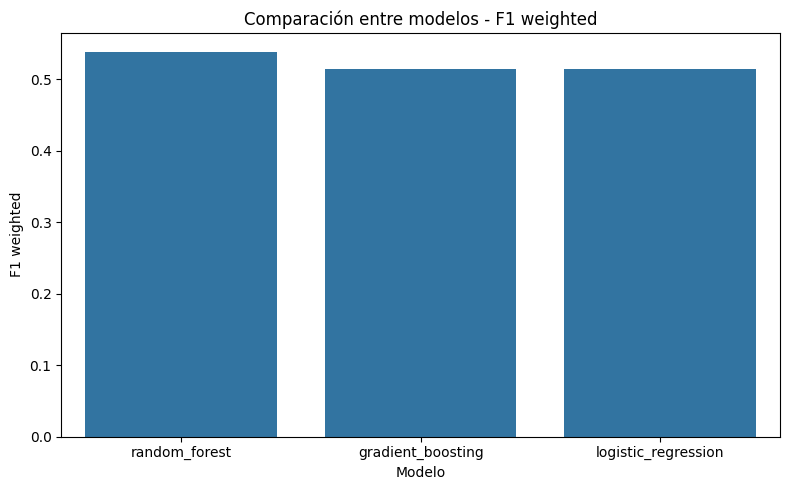

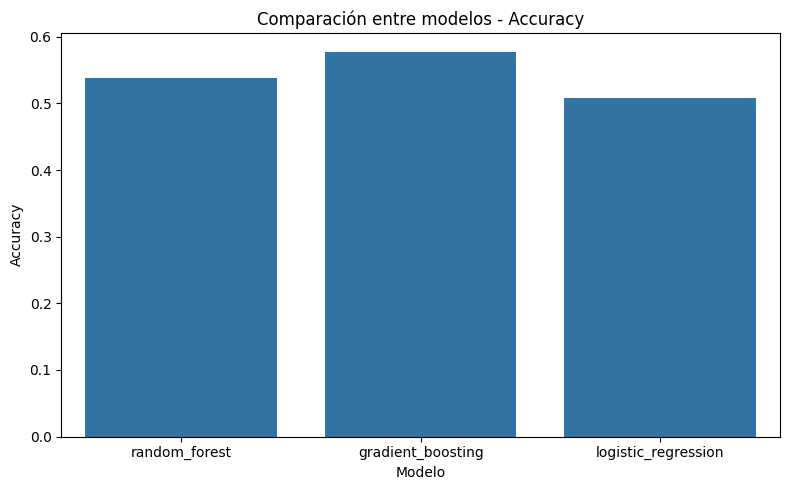

In [30]:
# Comparación Visual entre Modelos

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="model", y="test_f1_weighted")
plt.title("Comparación entre modelos - F1 weighted")
plt.ylabel("F1 weighted")
plt.xlabel("Modelo")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="model", y="test_accuracy")
plt.title("Comparación entre modelos - Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Modelo")
plt.tight_layout()
plt.show()


IMPORTANCIA DE VARIABLES - logistic_regression


,feature,importance
9,log_home_rank_points,0.874526
10,log_away_rank_points,0.644638
7,rank_points_ratio,0.539691
16,has_shootout,0.255041
27,tourn_African Friendship Games,0.147395
6,rank_points_sum,0.089516
5,rank_position_diff,0.082981
15,neutral,0.082421
3,away_rank_points,0.079349
144,tourn_Muratti Vase,0.073707


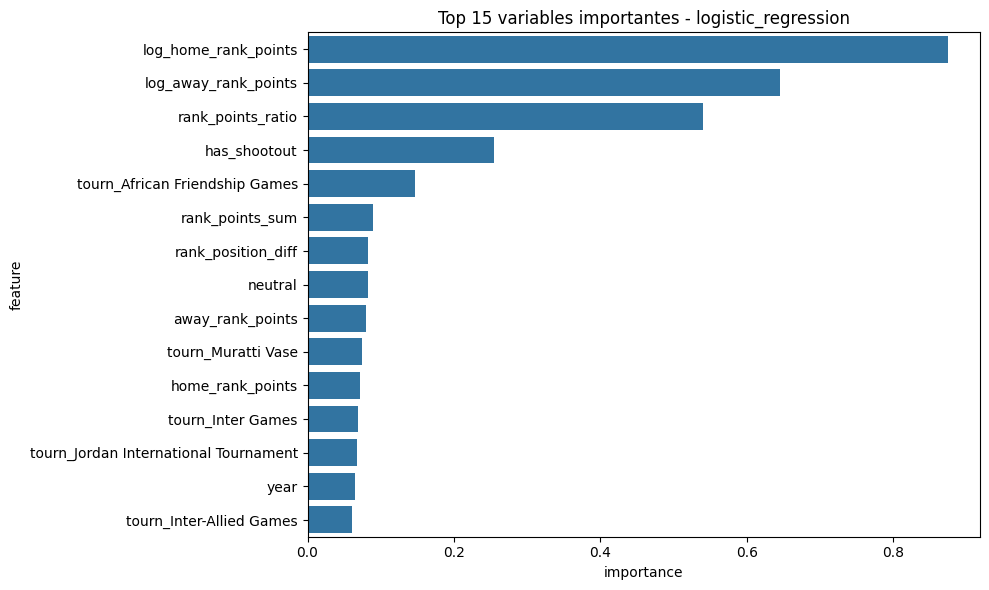


IMPORTANCIA DE VARIABLES - random_forest


,feature,importance
14,year,0.132834
4,rank_points_diff,0.082689
7,rank_points_ratio,0.079657
5,rank_position_diff,0.075156
8,abs_rank_points_diff,0.063252
6,rank_points_sum,0.056278
3,away_rank_points,0.049900
12,inv_away_rank_position,0.049522
10,log_away_rank_points,0.048551
9,log_home_rank_points,0.048111


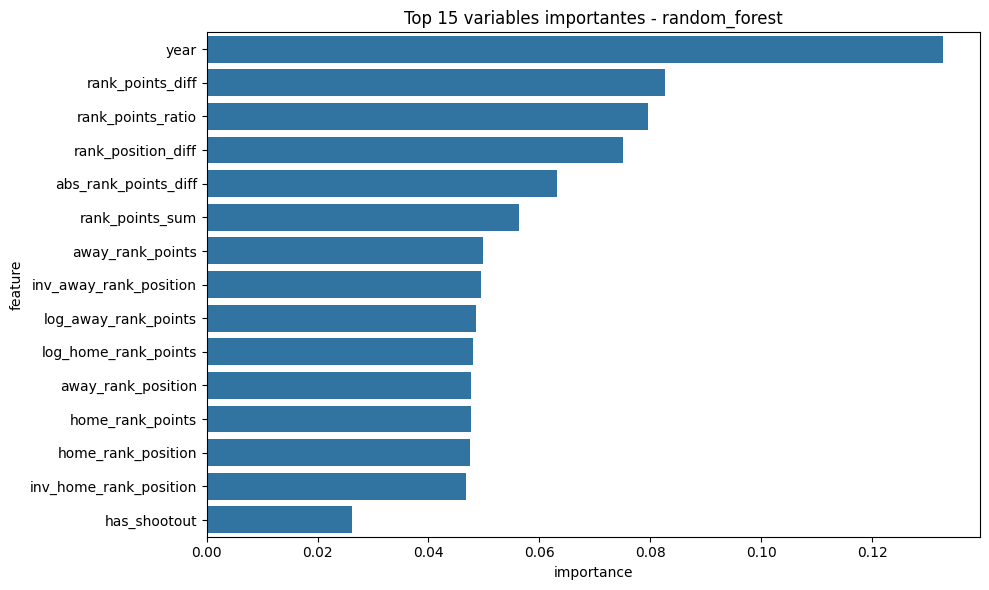


IMPORTANCIA DE VARIABLES - gradient_boosting


,feature,importance
7,rank_points_ratio,0.357450
4,rank_points_diff,0.116773
16,has_shootout,0.094391
14,year,0.070362
5,rank_position_diff,0.052508
2,away_rank_position,0.043312
8,abs_rank_points_diff,0.038120
0,home_rank_position,0.023873
6,rank_points_sum,0.020791
15,neutral,0.017519


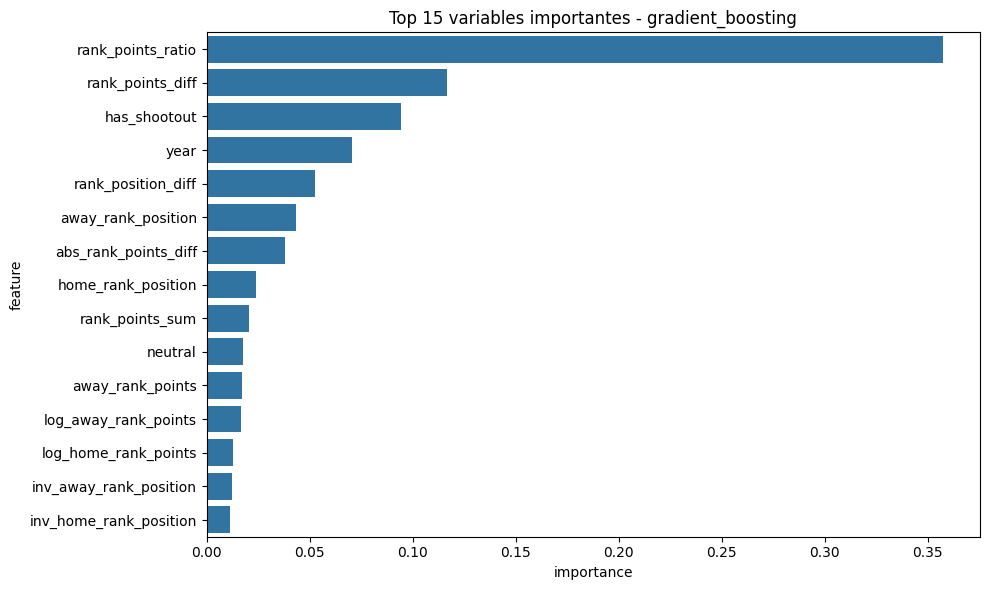

In [31]:
# Importancia de Variables

for model_name, pipeline_model in best_models.items():
    print_section(f"IMPORTANCIA DE VARIABLES - {model_name}")
    final_model = pipeline_model.named_steps["model"]
    plot_feature_importance(model_name, final_model, X_train.columns.tolist())

In [ ]:
# Ablation para Hipótesis (H1/H2/H3)

def build_feature_sets(df, all_features):
    rank_related = [c for c in all_features if any(k in c for k in ["rank", "points", "position"])]
    contextual = [c for c in all_features if (c in ["neutral", "has_shootout", "year"] or c.startswith("tourn_"))]
    recent_form_features = [c for c in all_features if any(k in c.lower() for k in [
        "recent", "form", "last", "streak", "avg_", "win_rate", "draw_rate", "loss_rate"
    ])]

    feature_sets = {
        "ranking_only": sorted(list(set(rank_related))),
        "context_only": sorted(list(set(contextual))),
        "ranking_plus_context": sorted(list(set(rank_related + contextual)))
    }

    if len(recent_form_features) > 0:
        feature_sets["recent_only"] = sorted(list(set(recent_form_features)))
        feature_sets["ranking_plus_recent"] = sorted(list(set(rank_related + recent_form_features)))
        feature_sets["ranking_recent_context"] = sorted(list(set(rank_related + recent_form_features + contextual)))

    feature_sets = {k: v for k, v in feature_sets.items() if len(v) > 0}
    return feature_sets

In [33]:
# Ejecución de Ablation

def run_feature_ablation(df, y, feature_sets):
    rows = []

    for set_name, feat_list in feature_sets.items():
        X_subset = df[feat_list]

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_subset,
            y,
            test_size=TEST_SIZE,
            stratify=y,
            random_state=RANDOM_STATE
        )

        preprocessor = ColumnTransformer(
            transformers=[
                ("num", Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]), X_tr.columns.tolist())
            ],
            remainder="drop"
        )

        model = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(
                solver="lbfgs",
                max_iter=2000,
                class_weight="balanced"
            ))
        ])

        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)

        rows.append({
            "feature_set": set_name,
            "n_features": len(feat_list),
            "accuracy": round(accuracy_score(y_te, pred), 4),
            "precision_weighted": round(precision_score(y_te, pred, average="weighted", zero_division=0), 4),
            "recall_weighted": round(recall_score(y_te, pred, average="weighted", zero_division=0), 4),
            "f1_weighted": round(f1_score(y_te, pred, average="weighted", zero_division=0), 4)
        })

    return pd.DataFrame(rows).sort_values("f1_weighted", ascending=False)

,feature_set,n_features,accuracy,precision_weighted,recall_weighted,f1_weighted
2,ranking_plus_context,210,0.5089,0.5283,0.5089,0.5143
0,ranking_only,13,0.4872,0.5065,0.4872,0.4938
1,context_only,197,0.3974,0.4326,0.3974,0.4042


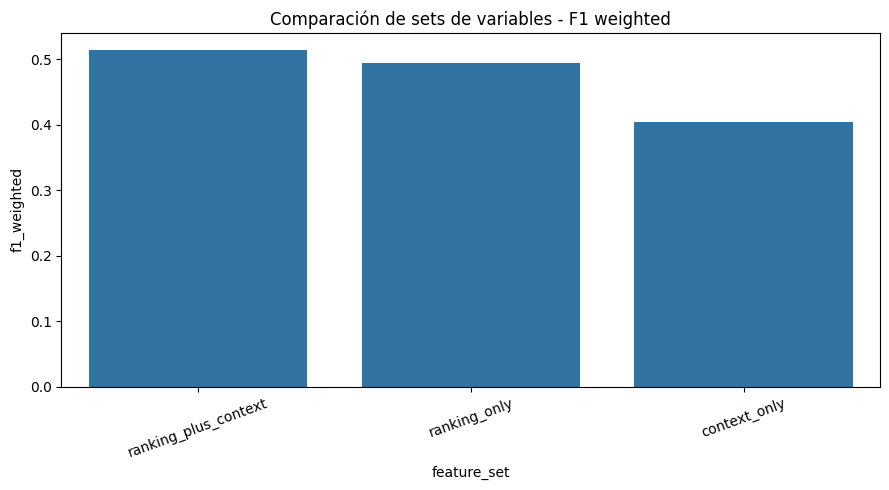

In [34]:
# Resultados de Ablation

if RUN_FEATURE_ABLATION:
    feature_sets = build_feature_sets(df, features)
    ablation_df = run_feature_ablation(df, y, feature_sets)
    display(ablation_df)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=ablation_df, x="feature_set", y="f1_weighted")
    plt.title("Comparación de sets de variables - F1 weighted")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

In [35]:
# Conclusión Automática para H4

lr_row = comparison_df.loc[comparison_df["model"] == "logistic_regression"]
rf_row = comparison_df.loc[comparison_df["model"] == "random_forest"]
gb_row = comparison_df.loc[comparison_df["model"] == "gradient_boosting"]

if not lr_row.empty and not rf_row.empty and not gb_row.empty:
    lr_f1 = float(lr_row["test_f1_weighted"].iloc[0])
    rf_f1 = float(rf_row["test_f1_weighted"].iloc[0])
    gb_f1 = float(gb_row["test_f1_weighted"].iloc[0])

    if rf_f1 > lr_f1 and gb_f1 > lr_f1:
        conclusion_h4 = "H4 respaldada: ambos modelos ensemble superan a la Regresión Logística."
    elif rf_f1 > lr_f1 or gb_f1 > lr_f1:
        conclusion_h4 = "H4 parcialmente respaldada: al menos un modelo ensemble supera a la Regresión Logística."
    else:
        conclusion_h4 = "H4 no respaldada con esta ejecución: los ensemble no superan a la Regresión Logística."

    print(conclusion_h4)

H4 respaldada: ambos modelos ensemble superan a la Regresión Logística.


In [36]:
# Guardar tablas para el informa

cv_df.to_csv(OUTPUT_DIR / "cv_results_persona4.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_results_persona4.csv", index=False)
comparison_df.to_csv(OUTPUT_DIR / "comparison_results_persona4.csv", index=False)

if RUN_FEATURE_ABLATION and "ablation_df" in locals():
    ablation_df.to_csv(OUTPUT_DIR / "feature_ablation_persona4.csv", index=False)

print(f"Archivos guardados en: {OUTPUT_DIR.resolve()}")

Archivos guardados en: C:\TFM\TFM\modulo_7\outputs_persona4


## Conclusiones de la sección de evaluación y optimización

En esta etapa se incorporó validación cruzada estratificada, ajuste de hiperparámetros y comparación formal entre modelos, tal como exige la asignatura para los modelos supervisados. Se compararon Regresión Logística, Random Forest y Gradient Boosting utilizando accuracy, precision, recall, F1 score, matriz de confusión y AUC multiclase. Esto permite sustentar de forma metodológicamente más sólida la selección del modelo final y contrastar la hipótesis H4 del proyecto.